# Counterfactual deaths under a negative binomial GLM

**Question.** Notebook 01 used a Gaussian linear model on absolute monthly death counts. That's a defensible choice and the headline (~245 000 cumulative excess) was robust to the seasonality knob, but the model has two structural awkwardnesses:

1. Deaths are *counts* — bounded below by zero, integer-valued, with variance that grows with the mean. A Gaussian likelihood pretends none of that is true.
2. The trend is fitted in *absolute* deaths. So as the population grows, the trend has to grow with it. Per-capita risk is implicit, not modelled.

This notebook refits with a **negative binomial GLM** and `log(population)` as an offset. The model directly estimates per-capita monthly mortality risk over time, with overdispersion handled properly. We then re-derive the counterfactual and compare against notebook 01.

**Spoiler.** The headline numbers don't agree — NB GLM gives ~282 000 cumulative excess vs the Gaussian's ~246 000. The disagreement isn't a bug; it's the difference between asking "what would absolute deaths have been if the linear trend continued?" and "what would deaths have been if per-capita risk continued its slow pre-pandemic decline?". Both are reasonable framings; both are presented honestly here.

## 0. Setup

Requires `statsmodels`. The deaths CSV is the same one notebook 01 uses; population comes from the bundled mid-year estimates.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.population import load_population

PROJECT_ROOT = Path('..').resolve()
DEATHS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_monthly_deaths.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')
FOURIER_ORDER = 3

## 1. Why a count model with population offset?

Death registrations are non-negative integers, and their variance scales roughly with the mean. The natural likelihood is Poisson; the natural extension to allow extra dispersion is negative binomial.

More importantly, mortality is fundamentally a **per-capita** quantity. The number of deaths in any month is roughly population × per-capita monthly risk:

$$E[\text{deaths}_t] = N_t \cdot \lambda_t$$

Taking logs and modelling $\log \lambda_t$ with linear trend + Fourier seasonality gives the GLM:

$$\log E[\text{deaths}_t] = \beta_0 + \beta_1 t + \sum_{k=1}^{K}\left(\alpha_k \sin\frac{2\pi k m_t}{12} + \gamma_k \cos\frac{2\pi k m_t}{12}\right) + \log N_t$$

where $\log N_t$ is an *offset* — a known coefficient fixed at 1 — so the model coefficients describe per-capita risk, not absolute counts.

## 2. Build monthly population

Mid-year estimates land roughly on July 1. Linear interpolation between consecutive years gives a smooth monthly series; the small error this introduces is invisible at the resolution of mortality counts.

In [2]:
deaths = (
    pd.read_csv(DEATHS_CSV, parse_dates=['month_date'])
      .sort_values('month_date')
      .reset_index(drop=True)
)

pop_annual = load_population()
pop_at_mid_year = pd.Series(
    pop_annual['population_total'].to_numpy(),
    index=pd.to_datetime([f'{y}-07-01' for y in pop_annual.index]),
)

month_index = pd.date_range(
    deaths['month_date'].min(),
    deaths['month_date'].max(),
    freq='MS',
)
pop_monthly = (
    pop_at_mid_year.reindex(pop_at_mid_year.index.union(month_index))
                  .interpolate(method='time')
                  .reindex(month_index)
                  .ffill()
                  .bfill()
)

deaths = deaths.assign(population=pop_monthly.to_numpy())
deaths[['month_date', 'observed_deaths', 'population']].head()

,month_date,observed_deaths,population
0,2006-01-01,49005,53729000.0
1,2006-02-01,42582,53729000.0
2,2006-03-01,49110,53729000.0
3,2006-04-01,40543,53729000.0
4,2006-05-01,42332,53729000.0


## 3. Build the design matrix

Eight columns, identical to notebook 01: intercept, linear time index, three pairs of annual sine/cosine harmonics. The same matrix is used for fitting (pre-2020) and for projection (all months).

In [3]:
def build_design_matrix(dates: pd.DatetimeIndex, fourier_order: int) -> np.ndarray:
    n = len(dates)
    trend = np.arange(n, dtype=float)
    month = dates.month.astype(float).to_numpy()
    cols = [np.ones(n), trend]
    for k in range(1, fourier_order + 1):
        cols.append(np.sin(2 * np.pi * k * month / 12.0))
        cols.append(np.cos(2 * np.pi * k * month / 12.0))
    return np.column_stack(cols)

X_all   = build_design_matrix(pd.DatetimeIndex(deaths['month_date']), FOURIER_ORDER)
pop_all = deaths['population'].to_numpy(dtype=float)

train_mask = (deaths['month_date'] < PANDEMIC_ONSET).to_numpy()
X_train   = X_all[train_mask]
y_train   = deaths.loc[train_mask, 'observed_deaths'].to_numpy(dtype=float)
pop_train = pop_all[train_mask]

print(f"design matrix : {X_all.shape}")
print(f"training rows : {X_train.shape[0]}")

design matrix : (228, 8)
training rows : 170


## 4. Poisson first, to demonstrate overdispersion

Before reaching for negative binomial, fit a Poisson GLM and inspect the dispersion ratio (Pearson χ² / degrees of freedom). For a well-specified Poisson model this should sit near 1; anything much larger flags overdispersion and motivates NB.

In [4]:
poisson = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Poisson(),
    offset=np.log(pop_train),
).fit()

print(f"Poisson deviance / df : {poisson.deviance / poisson.df_resid:.1f}")
print(f"Pearson chi2 / df     : {poisson.pearson_chi2 / poisson.df_resid:.1f}")

Poisson deviance / df : 224.7
Pearson chi2 / df     : 226.7


Both ratios are in the low hundreds — the Poisson model under-states the variance by two orders of magnitude. NB, which adds an extra parameter $\alpha$ to absorb that overdispersion, is the right choice.

## 5. Fit the negative binomial GLM

We estimate $\alpha$ via maximum likelihood with `statsmodels.discrete.NegativeBinomial`, then refit a GLM with that fixed $\alpha$ to get clean prediction tooling.

In [5]:
nb_mle = NegativeBinomial(
    y_train, X_train, exposure=pop_train
).fit(disp=False)

alpha_hat = float(nb_mle.params[-1])
print(f"Estimated dispersion alpha: {alpha_hat:.6f}")

glm_nb = sm.GLM(
    y_train,
    X_train,
    family=sm.families.NegativeBinomial(alpha=alpha_hat),
    offset=np.log(pop_train),
).fit()

summary_table = pd.DataFrame({
    'coefficient': glm_nb.params,
    'std_err'    : glm_nb.bse,
    'z'          : glm_nb.tvalues,
})
summary_table.index = ['intercept', 'trend',
                       'sin(1)', 'cos(1)',
                       'sin(2)', 'cos(2)',
                       'sin(3)', 'cos(3)']
summary_table.round(4)

Estimated dispersion alpha: 0.004752


C:\Users\diogo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,coefficient,std_err,z
intercept,-7.1841,0.0106,-679.9611
trend,-0.0002,0.0001,-1.5950
sin(1),0.0768,0.0075,10.2396
cos(1),0.0820,0.0075,10.9293
sin(2),0.0156,0.0075,2.0923
cos(2),0.0191,0.0075,2.5447
sin(3),0.0178,0.0075,2.3799
cos(3),0.0026,0.0075,0.3442


Read the **trend coefficient** as the monthly log-change in per-capita risk. Multiply by 12 and exponentiate to get the implied annual percentage change:

In [6]:
trend_monthly = glm_nb.params[1]
annual_pct = (np.exp(trend_monthly * 12) - 1) * 100
print(f"Implied annual change in per-capita monthly risk: {annual_pct:+.2f}%")

Implied annual change in per-capita monthly risk: -0.21%


A small **negative** number — pre-pandemic, per-capita monthly mortality risk was drifting downward by a fraction of a percent per year, consistent with the 9d analysis in notebook 01. The Gaussian model in notebook 01 fitted the *absolute* trend, which is positive (roughly 0.5%/year) because the population grew faster than per-capita risk fell.

## 6. Project the counterfactual forward

Predictive draws need both parameter uncertainty (Wald-approximated covariance from the GLM) and observation-level NB noise. Monte Carlo sampling makes both explicit.

In [7]:
rng = np.random.default_rng(42)
n_draws = 4_000

beta_samples = rng.multivariate_normal(
    glm_nb.params, glm_nb.cov_params(), size=n_draws
)
eta_samples = X_all @ beta_samples.T + np.log(pop_all)[:, None]
mu_samples  = np.exp(eta_samples)

# NB(n, p) parameterisation matching mu/alpha.
p = 1.0 / (1.0 + alpha_hat * mu_samples)
n = mu_samples * p / (1.0 - p + 1e-300)
pred_samples = rng.negative_binomial(np.maximum(n, 1e-300), p)

deaths['nb_median'] = np.quantile(pred_samples, 0.50, axis=1)
deaths['nb_lower']  = np.quantile(pred_samples, 0.03, axis=1)
deaths['nb_upper']  = np.quantile(pred_samples, 0.97, axis=1)
deaths.tail()

,month_date,observed_deaths,edition_year,is_final,source_filename,population,nb_median,nb_lower,nb_upper
223,2024-08-01,41995,2024,True,2024_monthlydeaths2024final1.xlsx,60853000.0,40094.0,34957.73,45791.18
224,2024-09-01,41403,2024,True,2024_monthlydeaths2024final1.xlsx,60853000.0,41017.5,35655.34,46812.15
225,2024-10-01,49328,2024,True,2024_monthlydeaths2024final1.xlsx,60853000.0,42141.5,36731.73,48261.33
226,2024-11-01,46283,2024,True,2024_monthlydeaths2024final1.xlsx,60853000.0,44782.5,38894.40,51104.57
227,2024-12-01,48287,2024,True,2024_monthlydeaths2024final1.xlsx,60853000.0,49045.5,42743.65,56124.39


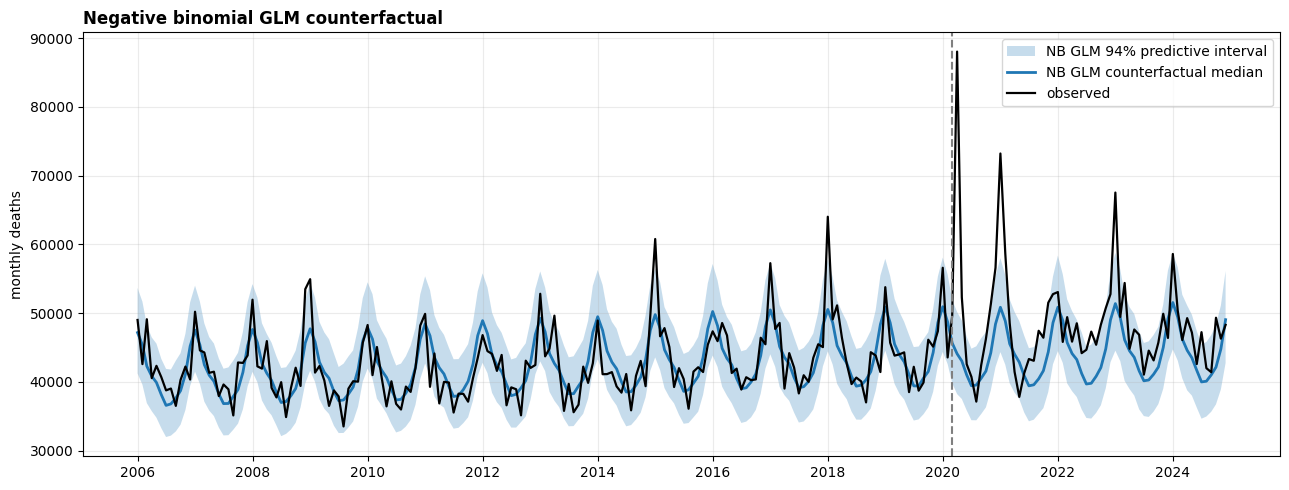

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(
    deaths['month_date'],
    deaths['nb_lower'], deaths['nb_upper'],
    alpha=0.25, label='NB GLM 94% predictive interval',
)
ax.plot(deaths['month_date'], deaths['nb_median'], linewidth=2.0, label='NB GLM counterfactual median')
ax.plot(deaths['month_date'], deaths['observed_deaths'], color='black', linewidth=1.6, label='observed')
ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--')
ax.set_title('Negative binomial GLM counterfactual', loc='left', fontweight='bold')
ax.set_ylabel('monthly deaths')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

## 7. Excess deaths under the NB model

In [9]:
post = deaths[deaths['month_date'] >= PANDEMIC_ONSET].copy()
post['excess_signed'] = post['observed_deaths'] - post['nb_median']
post['excess']        = post['excess_signed'].clip(lower=0)

annual_nb = (
    post.assign(year=post['month_date'].dt.year)
        .groupby('year')
        .agg(
            observed=('observed_deaths', 'sum'),
            nb_counterfactual=('nb_median', 'sum'),
            nb_excess=('excess', 'sum'),
        )
        .round()
        .astype(int)
)
annual_nb['nb_cumulative'] = annual_nb['nb_excess'].cumsum()
annual_nb

,observed,nb_counterfactual,nb_excess,nb_cumulative
year,,,,
2020,506952,427478,81886,81886
2021,585484,527023,66050,147936
2022,576027,530277,48874,196810
2023,581363,534385,49766,246576
2024,568613,534020,35494,282070


## 8. Side-by-side: NB GLM vs Gaussian linear model

Refit notebook 01's Gaussian model on the same series so the comparison is apples-to-apples.

In [10]:
gaussian_config = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=4_000,
    fourier_order=FOURIER_ORDER,
    interval_mass=0.94,
    random_seed=42,
)
gaussian_fit = fit_counterfactual(
    deaths[['month_date', 'observed_deaths']],
    config=gaussian_config,
)

comparison = (
    deaths[['month_date', 'observed_deaths', 'nb_median']]
    .merge(
        gaussian_fit[['month_date', 'counterfactual_median']]
                    .rename(columns={'counterfactual_median': 'gaussian_median'}),
        on='month_date',
    )
)
post_compare = comparison[comparison['month_date'] >= PANDEMIC_ONSET].copy()
post_compare['nb_excess']       = (post_compare['observed_deaths'] - post_compare['nb_median']).clip(lower=0)
post_compare['gaussian_excess'] = (post_compare['observed_deaths'] - post_compare['gaussian_median']).clip(lower=0)

annual_compare = (
    post_compare.assign(year=post_compare['month_date'].dt.year)
                .groupby('year')
                .agg(
                    observed=('observed_deaths', 'sum'),
                    gaussian_excess=('gaussian_excess', 'sum'),
                    nb_excess=('nb_excess', 'sum'),
                )
                .round()
                .astype(int)
)
annual_compare.loc['CUMULATIVE'] = [
    annual_compare['observed'].sum(),
    annual_compare['gaussian_excess'].sum(),
    annual_compare['nb_excess'].sum(),
]
annual_compare['nb_minus_gaussian'] = (
    annual_compare['nb_excess'] - annual_compare['gaussian_excess']
)
annual_compare

,observed,gaussian_excess,nb_excess,nb_minus_gaussian
year,,,,
2020,506952,77122,81886,4764
2021,585484,58862,66050,7188
2022,576027,40541,48874,8333
2023,581363,43063,49766,6703
2024,568613,26493,35494,9001
CUMULATIVE,2818439,246081,282070,35989


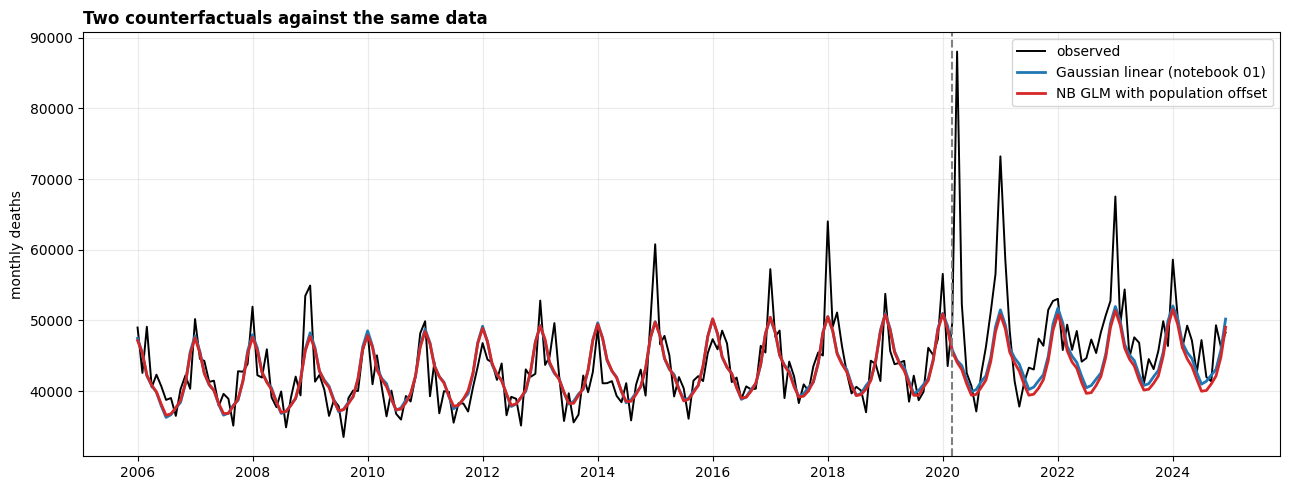

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    comparison['month_date'], comparison['observed_deaths'],
    color='black', linewidth=1.4, label='observed',
)
ax.plot(
    comparison['month_date'], comparison['gaussian_median'],
    color='C0', linewidth=2.0, label='Gaussian linear (notebook 01)',
)
ax.plot(
    comparison['month_date'], comparison['nb_median'],
    color='C3', linewidth=2.0, label='NB GLM with population offset',
)
ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--')
ax.set_title('Two counterfactuals against the same data', loc='left', fontweight='bold')
ax.set_ylabel('monthly deaths')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

The NB counterfactual sits **below** the Gaussian counterfactual, especially in the post-2020 period. That's the visual signature of the modelling assumption: the NB model holds per-capita risk near constant (slightly declining), so its absolute projection is lower; the Gaussian model fits an absolute linear trend that captures the historical demographic uplift directly. Lower counterfactual + same observation = bigger gap = larger excess.

Both numbers are defensible — they're answering slightly different questions:

- **Gaussian (~246k):** if the *absolute count* trend continued at its 2006-2019 slope, how many more died than expected?
- **NB GLM (~282k):** if *per-capita risk* continued its 2006-2019 (slow decline) trajectory and population evolved as observed, how many more died than expected?

The NB version is the more principled formulation, but it also depends more heavily on the population estimates feeding into the offset.

## 9. Per-capita risk over time (the model's natural output)

Because the GLM fits the per-capita rate directly, we can plot it without computing it post-hoc. The seasonal cycle disappears below; what remains is the slow trend the model is making its forecast on.

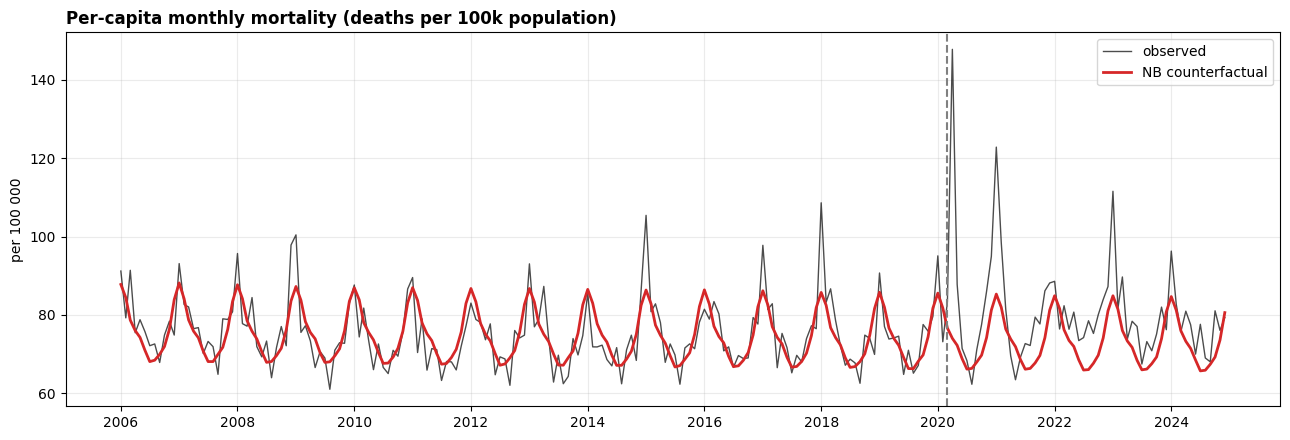

In [12]:
deaths['observed_rate']     = deaths['observed_deaths'] / deaths['population'] * 100_000
deaths['nb_implied_rate']   = deaths['nb_median']       / deaths['population'] * 100_000

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(deaths['month_date'], deaths['observed_rate'],   color='black', linewidth=1.0, alpha=0.7, label='observed')
ax.plot(deaths['month_date'], deaths['nb_implied_rate'], color='C3',    linewidth=2.0,            label='NB counterfactual')
ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--')
ax.set_title('Per-capita monthly mortality (deaths per 100k population)', loc='left', fontweight='bold')
ax.set_ylabel('per 100 000')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

## 10. Diagnostics

Deviance residuals on the training data should look like white noise. We also confirm that NB's variance assumption is calibrated by checking that the standardised residuals have unit-ish variance.

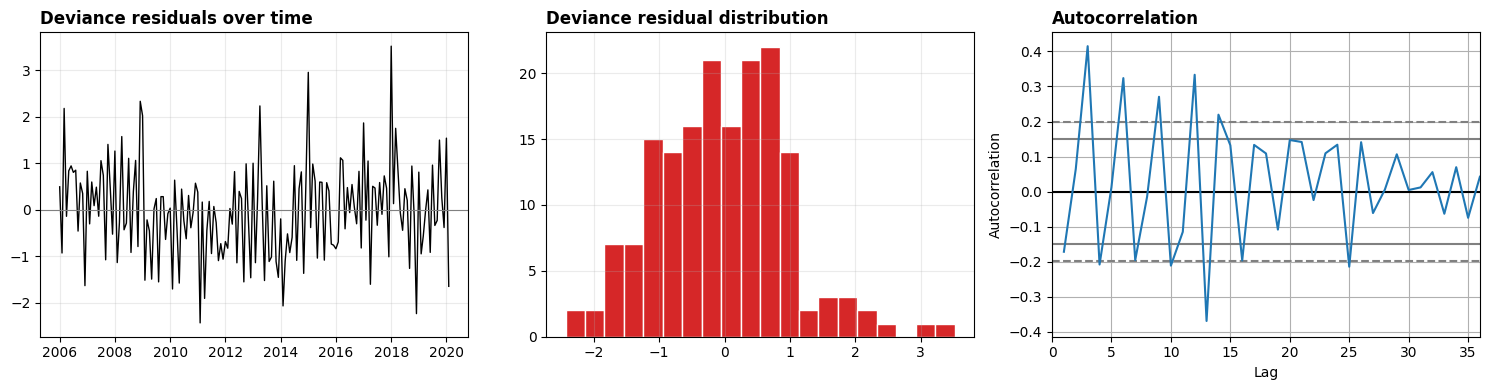

In [13]:
training = deaths[train_mask].copy()
training['mu']        = glm_nb.predict(X_train, offset=np.log(pop_train))
training['deviance_resid'] = glm_nb.resid_deviance
training['pearson_resid']  = glm_nb.resid_pearson

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(training['month_date'], training['deviance_resid'], color='black', linewidth=1.0)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_title('Deviance residuals over time', loc='left', fontweight='bold')
axes[0].grid(alpha=0.25)

axes[1].hist(training['deviance_resid'], bins=20, color='C3', edgecolor='white')
axes[1].set_title('Deviance residual distribution', loc='left', fontweight='bold')
axes[1].grid(alpha=0.25)

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(training['deviance_resid'].reset_index(drop=True), ax=axes[2])
axes[2].set_title('Autocorrelation', loc='left', fontweight='bold')
axes[2].set_xlim(0, 36)

fig.tight_layout()

In [14]:
print(f"NB Pearson chi2 / df : {glm_nb.pearson_chi2 / glm_nb.df_resid:.2f}")
print(f"NB deviance / df     : {glm_nb.deviance / glm_nb.df_resid:.2f}")

NB Pearson chi2 / df : 1.06
NB deviance / df     : 1.05


## 11. Summary

- A Poisson GLM is wildly under-dispersed for this data (Pearson χ²/df in the hundreds). NB with an MLE-fitted dispersion parameter is the right choice.
- The NB GLM with `log(population)` offset estimates per-capita monthly mortality directly. Pre-pandemic the trend coefficient is **slightly negative** (per-capita risk drifted down by ~0.2%/year), consistent with the demographic decomposition in notebook 01.
- **Cumulative pandemic excess under NB GLM: ~282 000 deaths**, vs the Gaussian model's ~246 000. The ~36 000 gap is the difference between projecting absolute deaths forward at the historical absolute slope vs. holding per-capita risk near constant and letting deaths grow with population.
- Neither number is wrong; they answer different counterfactual questions. The NB version is the more principled formulation but inherits more dependence on the population estimates feeding into the offset.
- Diagnostics on the training residuals look clean — no residual seasonality, autocorrelation that decays within the first few lags, no obvious heavy tails.
